# Preços médios de carros no Brasil

### O presente projeto tem o objetivo de entender como os preços dos carros variam no Brasil de acordo com sua marca, idade, combustivel e modelo.

site para base https://www.kaggle.com/datasets/mos3santos/conjunto-de-dados-de-preos-de-carros/data

Para base desse projeto, foram traduzidas os nomes das colunas e linhas

# 1. Importando bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Importação da Base

In [2]:
#lendo nossa base
base_original=pd.read_excel("car_price.xlsx")

#pré-visualização
base_original.head(3) 

,marca,modelo,ano,tamanho_motor,combustivel,transmissao,kilometragem,portas,numero_de_donos,preco
0,Kia,Rio,2020,42,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,20,Hibrido,Automatico,5356,2,3,12092
2,Mercedes,GLA,2020,42,Diesel,Automatico,231440,4,2,11171


# 3. Analise Exploratoria de Dados

In [3]:
#Podemos comecar calculando a media do preco medio
base_original['preco'].mean()

8852.9644

In [4]:
#Calulando a mediana
base_original['preco'].median()

8858.5

In [5]:
#menor preço
base_original['preco'].min()

2000

In [6]:
#menor preço
base_original['preco'].max()

18301

Temos um grande numero de outliers, com valores extremamente altos, ou seja carro com valores muito alto estão afetando bastante nossa analise

Text(0.5, 0.98, 'Boxplot do preco dos veiculos em relacao ao tipo de combustivel')

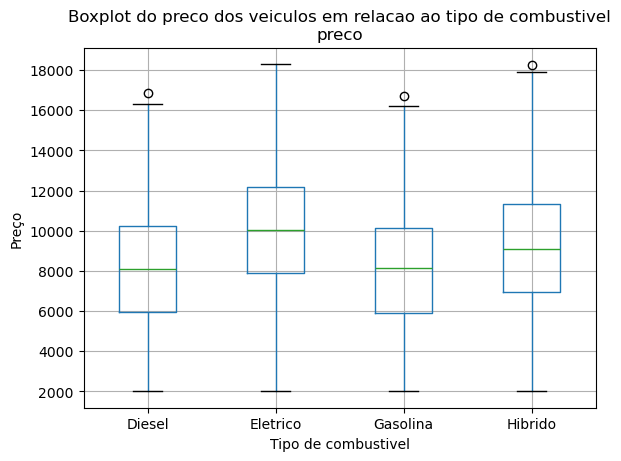

In [7]:
ax=base_original.boxplot(by='combustivel', column='preco')
ax.set_ylabel('Preço')
ax.set_xlabel('Tipo de combustivel')
plt.suptitle('Boxplot do preco dos veiculos em relacao ao tipo de combustivel')


Conseguimos ver do boxplot tendem a ter um valor maior, carros diesel possuem valores próximos aos de gasolina. Carros  hibridos tendem a ter um valor maior que os Diesel e Gasolina, mas mais baratos que elétricos.

Outro ponto interessante é em relação aos outliers (circulos), apenas os elétricos não possuem, indicando que esses tendem a ter valores mais estaveis comparado aos outros tipos de combustiveis.

Text(0.5, 1.0, 'Preço em relacao ao tipo de combustivel')

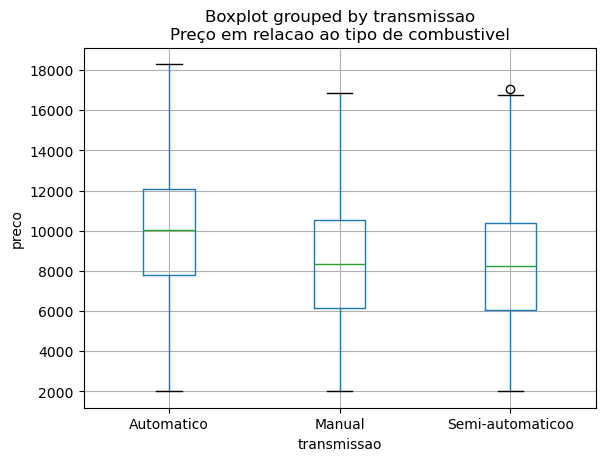

In [8]:
ax=base_original.boxplot(by='transmissao', column='preco')
ax.set_xlabel('transmissao')
ax.set_ylabel('preco')
plt.title('Preço em relacao ao tipo de combustivel')

Text(0.5, 1.0, 'Preco em relacao ao numero de portas')

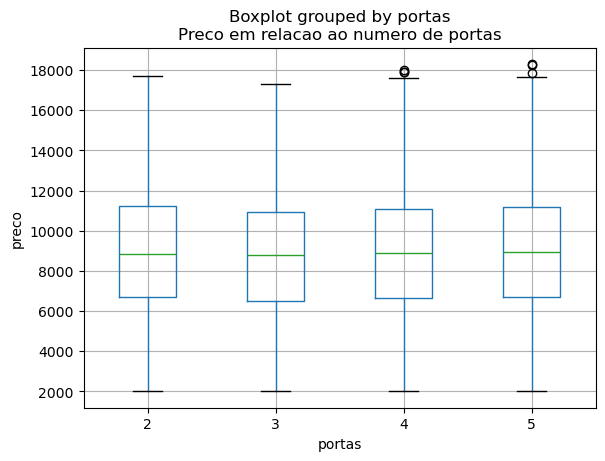

In [9]:
ax=base_original.boxplot(by='portas', column='preco')
ax.set_xlabel('portas')
ax.set_ylabel('preco')
plt.title('Preco em relacao ao numero de portas')

Text(0, 0.5, 'preco')

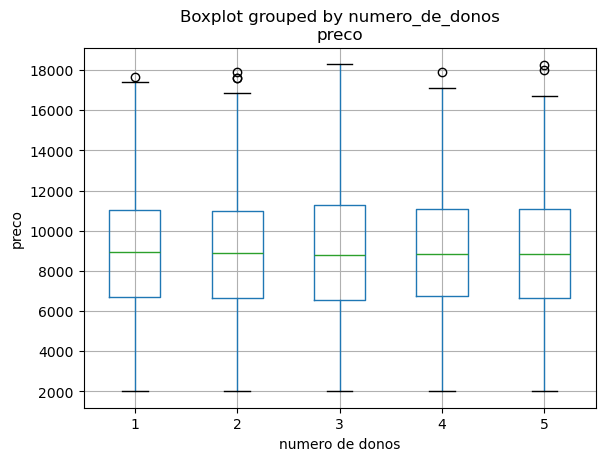

In [10]:
ax=base_original.boxplot(by='numero_de_donos', column='preco')
ax.set_xlabel('numero de donos')
ax.set_ylabel('preco')

In [11]:
base_original['preco'].quantile([0.05,0.25,0.5,0.75,0.95])

0.05     3655.00
0.25     6646.00
0.50     8858.50
0.75    11086.50
0.95    13981.05
Name: preco, dtype: float64

Com o método quantile, podemos ver que até 50% de nossa base está com valores abaixo de 8858, e 25% com valores acima de 11086,50.

Text(0.5, 0, 'Preço médio')

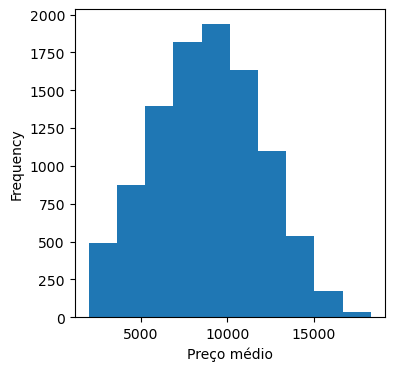

In [12]:
ax = base_original["preco"].plot.hist(figsize=(4,4))

ax.set_xlabel("Preço médio")

## podemos ver pelo histograma, que maior pate dos carros possuem um preço próximo entre 9000-10000

In [14]:
#Criando um dataframe com variáveis numericas
variaveis_numericas=base_original[['ano','tamanho_motor','kilometragem','portas','numero_de_donos','preco']]
variaveis_numericas

,ano,tamanho_motor,kilometragem,portas,numero_de_donos,preco
0,2020,42,289944,3,5,8501
1,2012,20,5356,2,3,12092
2,2020,42,231440,4,2,11171
3,2023,20,160971,2,1,11780
4,2003,26,286618,3,3,2867
...,...,...,...,...,...,...
9995,2004,37,5794,2,4,8884
9996,2002,14,168000,2,1,6240
9997,2010,30,86664,5,1,9866
9998,2002,14,225772,4,1,4084


In [15]:
#criando uma matriz de correlação
variaveis_numericas.corr()

,ano,tamanho_motor,kilometragem,portas,numero_de_donos,preco
ano,1.000000,-0.001306,-0.002476,0.014867,0.000116,0.663036
tamanho_motor,-0.001306,1.000000,0.015135,-0.009844,0.007122,0.357403
kilometragem,-0.002476,0.015135,1.000000,0.007879,0.006287,-0.551227
portas,0.014867,-0.009844,0.007879,1.000000,-0.005431,0.000511
numero_de_donos,0.000116,0.007122,0.006287,-0.005431,1.000000,0.002656
preco,0.663036,0.357403,-0.551227,0.000511,0.002656,1.000000


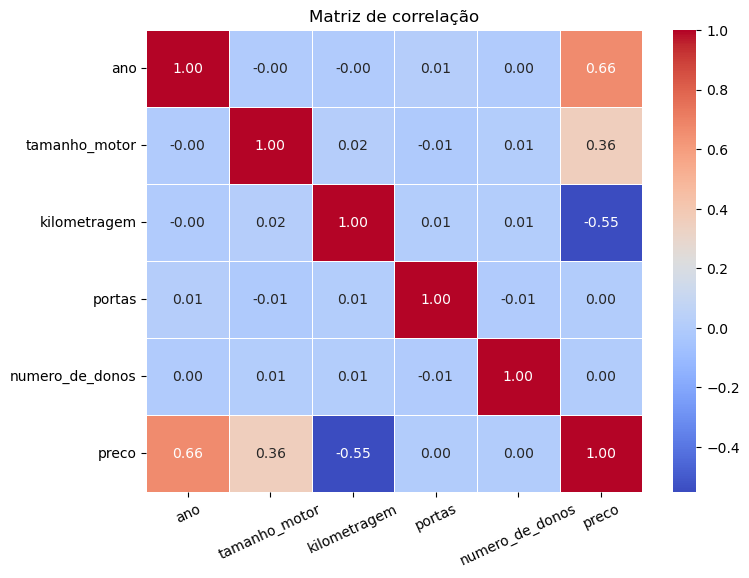

In [20]:
#Uma matriz mais apesentavel
import seaborn as sns
import matplotlib.pyplot as plt

matrix = variaveis_numericas.corr()

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.xticks(rotation=25)
plt.title("Matriz de correlação")
plt.show()